In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [ ]:
from langchain.globals import set_debug, set_verbose
set_debug(False)
set_verbose(False)

In [ ]:
import sys
from pathlib import Path

root_dir = Path.cwd().parent 

if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

print("Added project root to path:", root_dir)

In [ ]:
from llm_setup import get_llms

provider = "openai" # "gemini"     <--- Switch Variant of Model here

(
    lab_tech_llm,
    triage_llm,
    diagnose_llm,
    critique_llm,
    synthesizer_llm
) = get_llms(provider=provider)

print(f"LLMs initialized using provider:{provider}")

In [ ]:
from pathlib import Path

def get_prompt(name):
    return Path(f'agents/{name.upper()}.md').read_text()

lab_prompt = get_prompt('lab')
triage_prompt = get_prompt('triage')
diagnosis_prompt = get_prompt('diagnosis')
critique_prompt = get_prompt('critique')
synthesizer_prompt = get_prompt('synthesizer')

print("Prompts loaded: lab_prompt, triage_prompt, diagnosis_prompt, critique_prompt, synthesizer_prompt")

In [ ]:
from typing import TypedDict, Dict, List, Any
from utils import add_trace, encode_image, invoke_llm, run_evaluation_in_batch
from retrieve_image import QdrantBiomedCLIPRetriever

import json

COLLECTION_NAME = "derm_vkb"
QDRANT_URL = "http://localhost:6333"

class DermState(TypedDict):
    patient_data: Dict[str, Any]
    image_path: str
    lab_report: Dict[str, Any]
    triage_result: Dict[str, Any]
    diagnose_result: Dict[str, Any]
    critique_report: Dict[str, Any]
    final_report: Dict[str, Any] 
    retrieved_cases: List[Dict[str, Any]]
    trace: List[Dict[str, Any]]
    
    
def lab_technician(state: DermState):
    image_path = state.get("image_path", "")
    image_data = encode_image(image_path)
    patient_data = state.get("patient_data", {})
    
    user_message = [
        { "type": "text", "text": "Process the following case and generate the initial report.\n" },
        { "type": "text", "text": f"Patient Data:\n {patient_data}\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } }
    ]
    
    try:
        lab_report = invoke_llm(lab_tech_llm, lab_prompt, user_message)  
        add_trace(state, agent="lab_technician", role="user", payload=lab_report)

    except Exception as e:
        print(f"Error occurred during feature extraction: {e}")
    
    return {
        "lab_report": lab_report
    }
    
def triage_node(state: DermState):
    lab_report = state.get("lab_report", {})
    image_data = encode_image(state.get("image_path", ""))
    
    user_message = [
        { "type": "text", "text": "Based on the following report AND the provided image, perform triage and classify the disease family.\n" },
        { "type": "text", "text": "Skin Lesion Image:\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } },
        { "type": "text", "text": f"Lab Report:\n{json.dumps(lab_report, ensure_ascii=False)}" },
    ]

    triage_result = invoke_llm(triage_llm, triage_prompt, user_message)
    add_trace(state, agent="triage", role="user", payload=triage_result)
    
    return {
        "triage_result": triage_result
    }
    
def diagnosis_node(state: DermState):
    lab_report = state.get("lab_report", {})
    is_melanocytic_flag = lab_report.get("patient_data", {}).get("is_melanocytic")
    triage_result = state.get("triage_result", {})
    image_path = state.get("image_path", "")
    image_data = encode_image(image_path)
    
    user_message = [
        {
            "type": "text",
            "text": "Provide a final diagnosis by synthesizing all available evidence and comparing the query image to the provided reference cases.\n"
        },
        { "type": "text", "text": "Skin Lesion Image:\n" },
        { "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{image_data}" } },
        { "type": "text", "text": f"Lab Report:\n{json.dumps(lab_report, ensure_ascii=False)}" },
        { "type": "text", "text": f"Triage Result:\n{json.dumps(triage_result, ensure_ascii=False)}" },
    ]

    retriever = QdrantBiomedCLIPRetriever(collection=COLLECTION_NAME, qdrant_url=QDRANT_URL)
    retrieved_cases = retriever.search(image_path=image_path, is_melanocytic_filter=is_melanocytic_flag, k=3)

    if retrieved_cases:
        user_message.append({"type": "text", "text": "\nReference Cases:"})
        for i, case in enumerate(retrieved_cases):
            case_image = encode_image(case.get("image_path", ""))
            user_message.append({
                "type": "text",
                "text": f"Reference Case #{i + 1}: Diagnosis: {case['diagnosis']}, age: {case['age']}, sex: {case['sex']}, lesion_site: {case['anatom_site']}\n"
            })
            user_message.append({ "type": "image_url", "image_url": { "url": f"data:image/jpeg;base64,{case_image}" } }) 

    dx_result = invoke_llm(diagnose_llm, diagnosis_prompt, user_message)
    add_trace(state, agent="diagnose", role="user", payload=dx_result)

    return {
        "diagnose_result": dx_result,
        "retrieved_cases": retrieved_cases
    }

def critique_node(state: DermState):
    lab_report = state.get("lab_report", {})
    triage_result = state.get("triage_result", {})
    diagnose_result = state.get("diagnose_result", {})
    
    user_message = [
        {"type": "text", "text": "Critically evaluate the following proposed diagnosis based on the full case file."},
        {"type": "text", "text": f"Lab Report:\n{json.dumps(lab_report, ensure_ascii=False)}"},
        {"type": "text", "text": f"Triage Result:\n{json.dumps(triage_result, ensure_ascii=False)}"},
        {"type": "text", "text": f"Proposed Diagnosis:\n{json.dumps(diagnose_result, ensure_ascii=False)}"},
    ]

    critique_report = invoke_llm(critique_llm, critique_prompt, user_message)
    add_trace(state, agent="critique", role="user", payload=critique_report)

    return {"critique_report": critique_report}
    
def synthesizer_node(state: DermState):
    diagnose_result = state.get("diagnose_result", {})
    critique_report = state.get("critique_report", {})
    
    user_message = [
        {"type": "text", "text": "Synthesize the initial diagnosis proposal and the following critique into a final, balanced report."},
        {"type": "text", "text": f"Initial Proposal:\n{json.dumps(diagnose_result, ensure_ascii=False)}"},
        {"type": "text", "text": f"Critical Review:\n{json.dumps(critique_report, ensure_ascii=False)}"},
    ]

    final_report = invoke_llm(synthesizer_llm, synthesizer_prompt, user_message)
    add_trace(state, agent="synthesizer", role="user", payload=final_report)

    return {"final_report": final_report}

In [15]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver

workflow = StateGraph(DermState)

workflow.add_node("lab_technician", lab_technician)
workflow.add_node("triage", triage_node)
workflow.add_node("diagnosis", diagnosis_node)
workflow.add_node("critique", critique_node) 
workflow.add_node("synthesizer", synthesizer_node) 

workflow.set_entry_point("lab_technician")

workflow.add_edge("lab_technician", "triage")
workflow.add_edge("triage", "diagnosis")
workflow.add_edge("diagnosis", "critique")
workflow.add_edge("critique", "synthesizer")
workflow.add_edge("synthesizer", END)

checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)

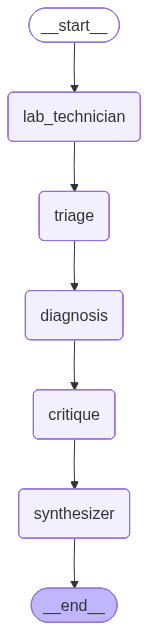

In [10]:
from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Error occurred while drawing the graph: {e}")

In [16]:
import pickle as pkl
from pathlib import Path

with open("../dataset/300_test_set.pkl", "rb") as f:
    test_set = pkl.load(f)
    
image_path = "../dataset/test"
for item in test_set:
    file_name = Path(item["image_path"]).name
    item["image_path"] = f"{image_path}/{file_name}"

In [11]:
test_set[0]

{'image_path': '../dataset/test/ISIC_0025686.jpg',
 'age': '65.0',
 'sex': 'male',
 'anatom_site': 'unknown',
 'diagnosis': 'Nevus',
 'melanocytic': True}

In [ ]:
OUTPUT_DIR = "../results"
# OUT_FILE = "final-gpt.jsonl"
OUT_FILE = "final-gemini.jsonl"

jsonl_file = run_evaluation_in_batch(app, test_set, out_dir=OUTPUT_DIR, out_file=OUT_FILE, resume=True)
print("JSONL at:", jsonl_file)